In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
import re

In [2]:
# Specify path to preprocessed dataset folder
preprocessed_dataset_path = '../PreprocessedDataNBHR_Mask/NBHR_physnet/test/NBHR_SizeW72_SizeH72_ClipLength128_DataTypeDiffNormalized_DataAugNone_LabelTypeDiffNormalized_Crop_faceTrue_BackendYOLO-Region_Large_boxTrue_Large_size1.5_Dyamic_DetTrue_det_len1_Median_face_boxTrue'

In [3]:
# Check if the preprocessed dataset path is valid
# If valid, gather metadata

# Get a list of all input files in the preprocessed dataset folder
input_files = [filename for filename in os.listdir(preprocessed_dataset_path) if filename.endswith(".npy") and re.match(r".*input\d+\.npy", filename)]
label_files = []

# Check if each input file has a corresponding label file
isValid = True
for input_file in input_files:
    label_filename = input_file.replace("input", "label")
    if label_filename not in os.listdir(preprocessed_dataset_path):
        isValid = False
        print(f"Label file {label_filename} is missing for input file {input_file}!")
    else:
        label_files.append(label_filename)
if isValid == True:
    print(f"{len(input_files)} input chunks and {len(label_files)} label chunks detected.")
    # Extract SizeW value
    match_size_w = re.search(r"SizeW(\d+)", preprocessed_dataset_path)
    size_w = match_size_w.group(1) if match_size_w else None

    # Extract SizeH value
    match_size_h = re.search(r"SizeH(\d+)", preprocessed_dataset_path)
    size_h = match_size_h.group(1) if match_size_h else None

    # Extract ClipLength value
    match_clip_length = re.search(r"ClipLength(\d+)", preprocessed_dataset_path)
    clip_length = match_clip_length.group(1) if match_clip_length else None

    print(f"Preprocessed data has a width of {size_w}, height of {size_h}, and a clip length of {clip_length}.")
else:
    print("Preprocessed dataset is invalid! Please delete the preprocessed dataset folder and try to preprocess it again.")

559 input chunks and 559 label chunks detected.
Preprocessed data has a width of 72, height of 72, and a clip length of 128.


Dropdown(description='Chunk:', index=531, layout=Layout(width='800px'), options=('20190827183933_input0.npy', …

IntSlider(value=0, description='Frame:', layout=Layout(width='800px'), max=127)

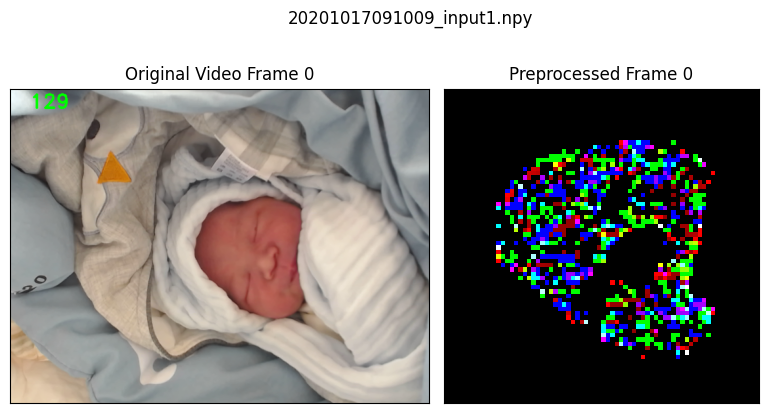

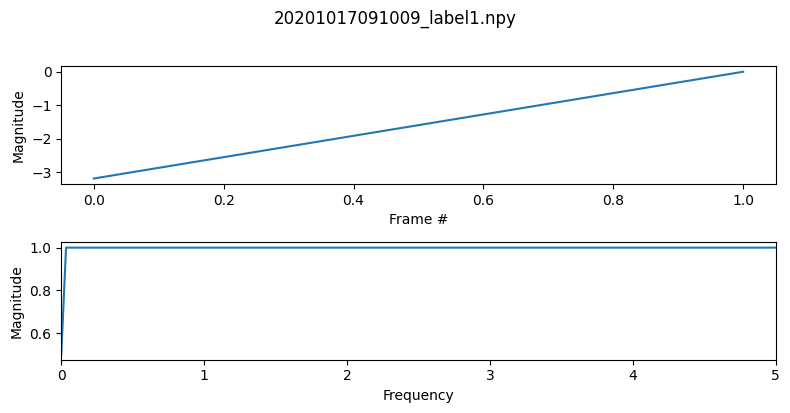

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from natsort import natsorted
import os
import scipy
from scipy.sparse import spdiags
from scipy.signal import butter
import math
from scipy import linalg
from scipy import signal
from scipy import sparse

class Visualizer:
    def __init__(self, preprocessed_dataset_path, input_files, label_files, original_video_path='/srv/data/rPPG_datasets/NBHR/video'):
        self.input_files = natsorted(input_files)
        self.label_files = natsorted(label_files)
        self.chunk_dropdown = None
        self.fig = None
        self.ax = None
        self.frame_index_slider = None
        self.current_chunk_index = 0
        self.current_frame_index = 0
        self.dataset_path = preprocessed_dataset_path
        self.original_video_path = original_video_path
        self.current_video_cap = None
        self.current_video_name = None

        self.create_visualization()

    def create_visualization(self):
        self.create_dropdown()
        self.create_figure()
        self.create_slider()

    def create_dropdown(self):
        # Chunk dropdown
        self.chunk_dropdown = widgets.Dropdown(
            options=self.input_files,
            description='Chunk:',
            layout=widgets.Layout(width='800px'),
            value=self.input_files[0] if self.input_files else None  # Set initial value to first chunk
        )
        self.chunk_dropdown.observe(self.chunk_selection_changed, names='value')

        # Display dropdown
        display(self.chunk_dropdown)

    def create_figure(self):
        self.fig, (self.ax_original, self.ax_preprocessed) = plt.subplots(1, 2, figsize=(14, 4))
        self.fig.tight_layout()
        self.ax_original.set_xticks([])
        self.ax_original.set_yticks([])
        self.ax_preprocessed.set_xticks([])
        self.ax_preprocessed.set_yticks([])
        self.ax_original.set_title("Original Video Frame")
        self.ax_preprocessed.set_title("After Diff-Normalization")

    def create_slider(self):
        num_frames = self.get_num_frames()
        self.frame_index_slider = widgets.IntSlider(
            min=0,
            max=num_frames - 1,
            step=1,
            value=0,
            description='Frame:',
            layout=widgets.Layout(width='800px')
        )
        self.frame_index_slider.observe(self.frame_index_changed, names='value')

        # Display slider
        display(self.frame_index_slider)

    def chunk_selection_changed(self, change):
        selected_chunk = change.new
        self.current_chunk_index = self.input_files.index(selected_chunk)
        self.current_frame_index = 0
        self.frame_index_slider.value = 0
        self.frame_index_slider.max = self.get_num_frames() - 1
        self.update_frame()

    def frame_index_changed(self, change):
        self.current_frame_index = change.new
        self.update_frame()

    def get_num_frames(self):
        input_file = self.input_files[self.current_chunk_index]
        return np.load(os.path.join(self.dataset_path, input_file)).shape[0]

    def load_original_video_frame(self, video_name, chunk_index, frame_index_in_chunk):
        """Load a frame from the original video file."""
        # Extract video filename without extension and chunk info
        # Format: videoname_input0.npy -> videoname.avi
        video_base_name = video_name.replace('_input' + str(chunk_index) + '.npy', '')
        
        # Try different video extensions
        for ext in ['.avi', '.mp4', '.mov']:
            video_path = os.path.join(self.original_video_path, video_base_name + ext)
            if os.path.exists(video_path):
                break
        else:
            print(f"Could not find video file for {video_base_name}")
            return None
        
        # Open video if not already open or if different video
        if self.current_video_name != video_base_name:
            if self.current_video_cap is not None:
                self.current_video_cap.release()
            self.current_video_cap = cv2.VideoCapture(video_path)
            self.current_video_name = video_base_name
            print(f"Opened video: {video_path}")
        
        # Calculate absolute frame number
        clip_length = 128  # From config
        absolute_frame_index = chunk_index * clip_length + frame_index_in_chunk
        
        # Set frame position
        self.current_video_cap.set(cv2.CAP_PROP_POS_FRAMES, absolute_frame_index)
        ret, frame = self.current_video_cap.read()
        
        if ret:
            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            return frame_rgb
        else:
            print(f"Failed to read frame {absolute_frame_index} from video")
            return None
    
    
    def load_frame(self):
        input_file = self.input_files[self.current_chunk_index]
        input_data = np.load(os.path.join(self.dataset_path, input_file))
        print(f'The shape of the loaded chunk is {np.shape(input_data)}.')

        # Extract chunk index from filename (e.g., "videoname_input3.npy" -> 3)
        chunk_match = re.search(r'_input(\d+)\.npy', input_file)
        chunk_index = int(chunk_match.group(1)) if chunk_match else 0

        # Get preprocessed frame (always the first 3 channels)
        preprocessed_frame = input_data[self.current_frame_index, ..., :3]
        
        # Load original video frame
        original_frame = self.load_original_video_frame(input_file, chunk_index, self.current_frame_index)
        
        return original_frame, preprocessed_frame
    
    def create_label_figure(self):
        self.label_fig, (self.label_ax_time, self.label_ax_fft) = plt.subplots(2, 1, figsize=(8, 4))
        self.label_ax_time.set_xlabel('Frame #')
        self.label_ax_time.set_ylabel('Magnitude')
        self.label_ax_fft.set_xlabel('Frequency')
        self.label_ax_fft.set_ylabel('Magnitude')

    def update_label_frame(self):
        def _next_power_of_2(x):
            """Calculate the nearest power of 2."""
            return 1 if x == 0 else 2 ** (x - 1).bit_length()
        
        clear_output(wait=True)
        label_frame = self.load_label_frame()

        # Handle multi-dimensional labels by taking the first channel
        if label_frame.ndim > 1:
            label_frame = label_frame[:, 0]

        N = _next_power_of_2(label_frame.shape[0])
        fs = 30
        N = 30 * fs
        ppg_label_fft = label_frame
        ppg_label_f, ppg_label_pxx = scipy.signal.periodogram(ppg_label_fft, fs=fs, nfft=N, detrend=False)

        self.label_ax_time.clear()
        self.label_ax_fft.clear()

        self.label_ax_time.set_xlabel('Frame #')
        self.label_ax_time.set_ylabel('Magnitude')
        self.label_ax_time.plot(label_frame)

        self.label_ax_fft.set_xlabel('Frequency')
        self.label_ax_fft.set_ylabel('Magnitude')
        self.label_ax_fft.plot(ppg_label_f, ppg_label_pxx/ppg_label_pxx.max())

        self.label_ax_fft.set_xlim([0, 5])      # Set x-axis limits from 0 to 5 Hz

        self.label_fig.suptitle(self.label_files[self.current_chunk_index], y=1.02)
        self.label_fig.tight_layout()

    def load_label_frame(self):
        def _process_signal(signal):
            # Detrend and filter
            fs = 30
            diff_flag = False
            use_bandpass = True
            if diff_flag:  # if the predictions and labels are 1st derivative of PPG signal.
                gt_bvp = _detrend(np.cumsum(signal), 100)
            else:
                gt_bvp = _detrend(signal, 100)
            if use_bandpass:
                # bandpass filter between [0.75, 2.5] Hz
                # equals [45, 150] beats per min
                [b, a] = butter(1, [0.75 / fs * 2, 2.5 / fs * 2], btype='bandpass')
                signal = scipy.signal.filtfilt(b, a, np.double(signal))
            return signal


        def _detrend(input_signal, lambda_value):
            """Detrend PPG signal."""
            signal_length = input_signal.shape[0]
            # observation matrix
            H = np.identity(signal_length)
            ones = np.ones(signal_length)
            minus_twos = -2 * np.ones(signal_length)
            diags_data = np.array([ones, minus_twos, ones])
            diags_index = np.array([0, 1, 2])
            D = spdiags(diags_data, diags_index,
                        (signal_length - 2), signal_length).toarray()
            detrended_signal = np.dot(
                (H - np.linalg.inv(H + (lambda_value ** 2) * np.dot(D.T, D))), input_signal)
            return detrended_signal
        
        label_file = self.label_files[self.current_chunk_index]
        label_data = np.load(os.path.join(self.dataset_path, label_file))
        print(f'The shape of the loaded label file is {np.shape(label_data)}.')

        label_data = _process_signal(label_data)

        return label_data

    def update_frame(self):
        clear_output(wait=True)
        original_frame, preprocessed_frame = self.load_frame()

        if original_frame is not None:
            print(f"Original frame - min: {original_frame.min():.4f}, max: {original_frame.max():.4f}, mean: {original_frame.mean():.4f}")
        else:
            print("Could not load original video frame")
            
        print(f"Preprocessed frame - min: {preprocessed_frame.min():.4f}, max: {preprocessed_frame.max():.4f}, mean: {preprocessed_frame.mean():.4f}")

        self.ax_original.clear()
        self.ax_preprocessed.clear()
        
        # Handle original frame display
        if original_frame is not None:
            # Convert to float [0, 1] if needed
            if original_frame.dtype == np.uint8:
                original_frame_display = original_frame.astype(np.float32) / 255.0
            elif np.issubdtype(original_frame.dtype, np.floating):
                original_frame_display = np.clip(original_frame, 0, 1)
            else:
                original_frame_display = np.clip(original_frame, 0, 255) / 255.0
            
            self.ax_original.imshow(original_frame_display)
            self.ax_original.set_title(f"Original Video Frame {self.current_frame_index}")
        else:
            self.ax_original.text(0.5, 0.5, 'Could not load\noriginal video frame', 
                                 ha='center', va='center', fontsize=14, transform=self.ax_original.transAxes)
            self.ax_original.set_title("Original Video Frame (Not Available)")
        
        self.ax_original.set_xticks([])
        self.ax_original.set_yticks([])
        
        # Handle preprocessed frame display
        if np.issubdtype(preprocessed_frame.dtype, np.floating):
            preprocessed_frame_display = preprocessed_frame
        else:
            preprocessed_frame_display = np.clip(preprocessed_frame, 0, 255)
        
        self.ax_preprocessed.imshow(preprocessed_frame_display)
        self.ax_preprocessed.set_title(f"Preprocessed Frame {self.current_frame_index}")
        self.ax_preprocessed.set_xticks([])
        self.ax_preprocessed.set_yticks([])
        
        self.fig.suptitle(self.input_files[self.current_chunk_index], y=1.02)
        self.fig.tight_layout()
        self.update_label_frame()
        display(self.chunk_dropdown, self.frame_index_slider, self.fig, self.label_fig)


# Create the visualizer instance
visualizer = Visualizer(preprocessed_dataset_path, input_files, label_files)

# Create the label figure
visualizer.create_label_figure()

# Trigger initial display
visualizer.update_frame()